In [10]:
from datasets import load_dataset
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
from kagglehub import KaggleDatasetAdapter


https://www.kaggle.com/datasets/suchintikasarkar/sentiment-analysis-for-mental-health

In [11]:


# Set the path to the file you'd like to load
file_path = ""

# Load the latest version
df = pd.read_csv("mental_health_combineddata.csv")

In [12]:
df.columns

Index(['statement', 'status'], dtype='object')

In [14]:
# Check distribution (imbalance)
rating_counts = df["status"].value_counts().sort_index()
print("Class distribution:\n", rating_counts)

Class distribution:
 status
Anxiety                  3888
Bipolar                  2877
Depression              15404
Normal                  16351
Personality disorder     1201
Stress                   2669
Suicidal                10652
Name: count, dtype: int64


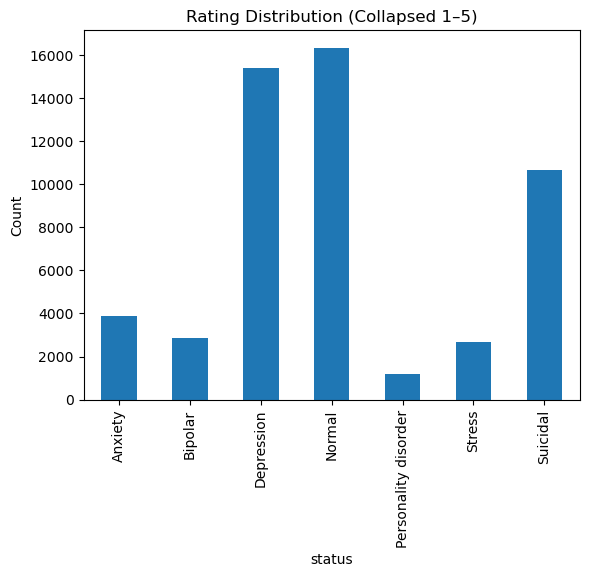

In [16]:
# df["rating_bucket"] = df["disease"]


# visualize the distribution
rating_counts.plot(kind="bar", title="Rating Distribution (Collapsed 1–5)")
plt.xlabel("status")
plt.ylabel("Count")
plt.show()

In [17]:
# Balance dataset (undersample the majority class for demonstration)
min_count = rating_counts.min()
balanced_df = df.groupby("status", group_keys=False).apply(
    lambda x: x.sample(min_count, random_state=42)
)

print("\nBalanced class distribution:\n", balanced_df["status"].value_counts())


Balanced class distribution:
 status
Anxiety                 1201
Bipolar                 1201
Depression              1201
Normal                  1201
Personality disorder    1201
Stress                  1201
Suicidal                1201
Name: count, dtype: int64


/var/folders/gj/bbgjz4_x5ybc58ms5zv9p8sr0000gp/T/ipykernel_995/3128115979.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  balanced_df = df.groupby("status", group_keys=False).apply(


In [18]:
balanced_df.head(10)


,statement,status
53020,My anxiety is telling me not to be honest/vuln...,Anxiety
35495,Worried I have ovarian cancer. The more I'm on...,Anxiety
35606,For HA Sufferers with different anxieties than...,Anxiety
35708,"Eye floaters from stress? Hello, I recently we...",Anxiety
315,"There is excessive anxiety today, .And, there ...",Anxiety
52796,how did buspirone/buspar make you feel? did yo...,Anxiety
351,Why is it that if there are a lot of people ta...,Anxiety
149,I need adit not for stalking or for strange th...,Anxiety
35461,Fuck lymph nodes I spent about two months comp...,Anxiety
457,confused and restless. This heart seems to die...,Anxiety


In [19]:
# save the balanced dataset to you current directory
balanced_df.to_csv("mental_health_balanced.csv")

Class distribution:
 status
Anxiety                 1201
Bipolar                 1201
Depression              1201
Normal                  1201
Personality disorder    1201
Stress                  1201
Suicidal                1201
Name: count, dtype: int64


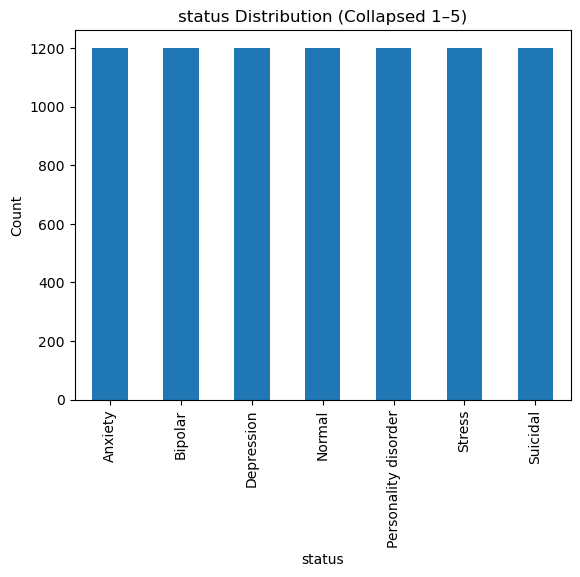

In [21]:
# Revalidate the balanced distribution
# Check distribution (imbalance)
rating_counts = balanced_df["status"].value_counts().sort_index()
print("Class distribution:\n", rating_counts)

# visualize
rating_counts.plot(kind="bar", title="status Distribution (Collapsed 1–5)")
plt.xlabel("status")
plt.ylabel("Count")
plt.show()

In [21]:
from transformers import pipeline

classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

text = "Tissue changes around loose prostheses. A canine model to investigate the effects of an antiinflammatory agent. The aseptically loosened prosthesis provided a means for investigating the in vivo and in vitro activity of the cells associated with the loosening process in seven dogs. The cells were isolated and maintained in culture for sufficient periods of time so that their biologic activity could be studied as well as the effect of different agents added to the cells in vivo or in vitro. The biologic response as determined by interleukin-1 and prostaglandin E2 activity paralleled the roentgenographic appearance of loosening and the technetium images and observations made at the time of revision surgery. The correlation between clinical, roentgenographic, histologic, and biochemical loosening indicates that the canine model is suitable for investigating the mechanisms of prosthetic failure. A canine model permits the study of possible nonsurgical therapeutic interventions with the ultimate hope of stopping or slowing the loosening process."
candidate_labels = df["condition_label"]

result = classifier(text, candidate_labels)
print(result)

2025-10-02 17:59:22.340057: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


ValueError: Your currently installed version of Keras is Keras 3, but this is not yet supported in Transformers. Please install the backwards-compatible tf-keras package with `pip install tf-keras`.